Rendering Context Window GIF...
Displaying The Context Window...



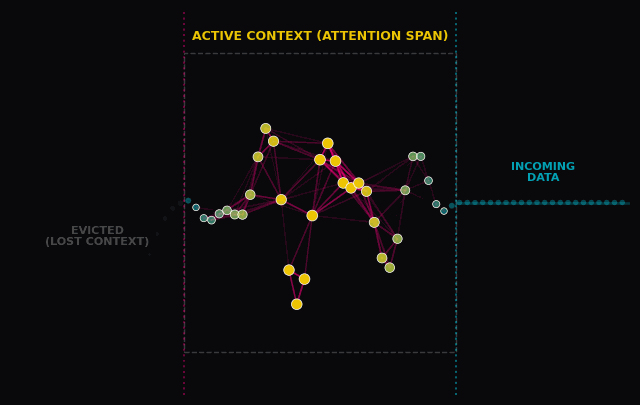

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image
import io
import base64
from IPython.display import display, HTML
import warnings

# Suppress warnings for clean output
warnings.filterwarnings("ignore")

# ---------------------------------------------------------
# Configuration & Theme
# ---------------------------------------------------------
FRAMES = 90
FPS = 30
BG_COLOR = "#08080b"  # Deep Void Black

# Set global Seaborn dark theme
sns.set_theme(style="dark", rc={
    "axes.facecolor": BG_COLOR,
    "figure.facecolor": BG_COLOR,
    "axes.edgecolor": "#111111",
    "text.color": "#e0e0e0",
})

def fig_to_image(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', facecolor=fig.get_facecolor(), dpi=100)
    buf.seek(0)
    return Image.open(buf).copy()

# ---------------------------------------------------------
# Visualizer: The Context Window
# ---------------------------------------------------------
def generate_context_window_gif(filename):
    print("Rendering Context Window GIF...")
    frames = []

    # 80 particles spaced by 0.2 units (Total span = 16 units, from -8 to 8)
    N = 80
    base_x = np.arange(-8, 8, 0.2)

    fig, ax = plt.subplots(figsize=(8, 5))

    for frame in range(FRAMES):
        ax.clear()
        t = frame / FRAMES # 0.0 to 1.0 (Loop progress)

        # Calculate phases for the perfect loop
        # The wave completes integer cycles over the 90 frames
        phase1 = t * 2 * np.pi * 3  # 3 forward oscillations
        phase2 = -t * 2 * np.pi * 2 # 2 backward oscillations

        # Shift particles by exactly 15 intervals (15 * 0.2 = 3.0 units) over the loop
        # This guarantees particle 'i' perfectly replaces particle 'i-15' at the end of the loop
        shift = t * 3.0
        x = ((base_x - shift) + 8) % 16 - 8

        y = np.zeros(N)
        colors = np.zeros((N, 4))
        sizes = np.zeros(N)

        # Calculate states for each token/particle based strictly on its x-coordinate
        for i in range(N):
            xi = x[i]

            if xi > 3.5:
                # 1. QUEUE: Incoming raw tokens
                y[i] = 0.0
                colors[i] = [0.0, 0.9, 1.0, 0.3] # Dim Cyan
                sizes[i] = 15

            elif xi >= -3.5:
                # 2. CONTEXT WINDOW: Active Processing
                # Envelope forces wave to 0 at the boundaries (-3.5 and 3.5)
                env = 1 - (xi / 3.5)**2

                # Dynamic "thinking" wave
                y[i] = env * (1.5 * np.sin(xi * 3 + phase1) + 1.0 * np.cos(xi * 5 + phase2))

                # Color morphs from Cyan -> Gold -> Cyan
                r = 0.0 + env * 1.0
                g = 0.9 - env * 0.1
                b = 1.0 - env * 1.0
                a = 0.3 + env * 0.7
                colors[i] = [r, g, b, a]

                # Size swells in the center
                sizes[i] = 15 + env * 45

            else:
                # 3. EVICTION: Forgotten Context
                # Tokens fall away parabolically once they cross x = -3.5
                y[i] = - (abs(xi) - 3.5)**2 * 1.5

                # Fade to dark grey
                fade = max(0.0, 1.0 - (abs(xi) - 3.5) / 1.5)
                colors[i] = [0.2, 0.2, 0.2, 0.5 * fade]
                sizes[i] = 15 * fade

        # --- DRAW ATTENTION MECHANISM (Connections) ---
        active_indices = [i for i in range(N) if -3.5 <= x[i] <= 3.5]
        for idx1 in range(len(active_indices)):
            for idx2 in range(idx1 + 1, len(active_indices)):
                i = active_indices[idx1]
                j = active_indices[idx2]

                dist = np.sqrt((x[i] - x[j])**2 + (y[i] - y[j])**2)

                if dist < 2.0: # Only connect nearby active tokens
                    env_i = 1 - (x[i]/3.5)**2
                    env_j = 1 - (x[j]/3.5)**2
                    # Opacity depends on proximity and how centered the nodes are
                    alpha = (1 - dist/2.0) * env_i * env_j * 0.9
                    ax.plot([x[i], x[j]], [y[i], y[j]], color="#FF007F", alpha=alpha, lw=1.2, zorder=1)

        # --- DRAW PARTICLES ---
        ax.scatter(x, y, c=colors, s=sizes, edgecolors='white', linewidths=0.5 * (sizes > 20), zorder=3)

        # --- ENVIRONMENT & DECORATIONS ---
        # Draw Context Window Box
        ax.add_patch(patches.Rectangle((-3.5, -3.5), 7.0, 7.0, fill=True, color='#FFFFFF', alpha=0.015, zorder=0))
        ax.add_patch(patches.Rectangle((-3.5, -3.5), 7.0, 7.0, fill=False, color='#FFFFFF', alpha=0.2, linestyle='--', zorder=0))

        # Window Boundaries
        ax.axvline(3.5, color='#00E5FF', linestyle=':', alpha=0.4, zorder=0)
        ax.axvline(-3.5, color='#FF007F', linestyle=':', alpha=0.4, zorder=0)

        # Incoming Queue Line
        ax.plot([3.5, 8], [0, 0], color='#00E5FF', alpha=0.2, lw=2, zorder=0)

        # Typography / Labels
        ax.text(5.75, 0.5, "INCOMING\nDATA", color='#00E5FF', alpha=0.7, fontsize=8, ha='center', fontweight='bold')
        ax.text(0, 3.8, "ACTIVE CONTEXT (ATTENTION SPAN)", color='#FFD700', alpha=0.9, fontsize=9, ha='center', fontweight='bold')
        ax.text(-5.75, -1.0, "EVICTED\n(LOST CONTEXT)", color='#666666', alpha=0.7, fontsize=8, ha='center', fontweight='bold')

        # Formatting
        ax.set_xlim(-8, 8)
        ax.set_ylim(-4.5, 4.5)
        ax.axis('off') # Remove all standard axes for a pure visual

        frames.append(fig_to_image(fig))

    plt.close(fig)
    frames[0].save(filename, save_all=True, append_images=frames[1:], duration=int(1000/FPS), loop=0)
    return filename

# ---------------------------------------------------------
# Execution & HTML Display
# ---------------------------------------------------------
file_context = generate_context_window_gif('context_window.gif')

def image_to_base64(filepath):
    with open(filepath, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

b64_context = image_to_base64(file_context)

print("Displaying The Context Window...")

html_code = f"""
<div style="display: flex; flex-direction: column; align-items: center; justify-content: center; font-family: 'Courier New', monospace; color: white; background-color: #08080b; padding: 40px; border-radius: 12px; border: 1px solid #222;">
    <div style="text-align: center; width: 90%; max-width: 800px;">
        <h2 style="color: #FFD700; font-size: 20px; margin-bottom: 5px; letter-spacing: 2px;">THE CONTEXT WINDOW</h2>
        <p style="color: #888; font-size: 12px; margin-bottom: 25px; text-transform: uppercase;">A visualization of Memory, Attention, and Forgetting in AI Systems</p>

        <img src="data:image/gif;base64,{b64_context}" style="border: 1px solid #333; border-radius: 6px; width: 100%; box-shadow: 0 10px 30px rgba(0,0,0,0.8);">

        <div style="display: flex; justify-content: space-between; font-size: 11px; margin-top: 25px; text-align: left; gap: 20px;">
            <div style="flex: 1; border-top: 2px solid #00E5FF; padding-top: 10px;">
                <span style="color: #00E5FF; font-weight: bold;">[ THE FUTURE ]</span><br>
                <span style="color: #999;">Raw, unprocessed tokens queue linearly. They possess no semantic relationships yet, existing purely as potential data waiting to be perceived.</span>
            </div>
            <div style="flex: 1; border-top: 2px solid #FFD700; padding-top: 10px;">
                <span style="color: #FFD700; font-weight: bold;">[ THE PRESENT ]</span><br>
                <span style="color: #999;">Tokens enter the compute boundary. The <i>Attention Mechanism</i> weaves a dense, glowing web of multidimensional context between them, extracting meaning.</span>
            </div>
            <div style="flex: 1; border-top: 2px solid #666666; padding-top: 10px;">
                <span style="color: #888888; font-weight: bold;">[ THE PAST ]</span><br>
                <span style="color: #999;">As limits are reached, old data is pushed out. Connections snap, context dissolves, and information drops into the void of forgotten memory.</span>
            </div>
        </div>
    </div>
</div>
"""

display(HTML(html_code))